<a href="https://colab.research.google.com/github/harpuneet-k/Celebal-Assignments/blob/main/Assignment7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ASSIGNMENT 7**

Develop a web application using Streamlit to deploy a trained machine learning model. The app should allow users to input data, receive predictions, and understand model outputs through visualizations. This task will help you learn how to make your models accessible and interactive.


Here is a step by step procedure:

 Step 1: Train & Save Your ML Model

 Step 2: Build the Streamlit App

 Step 3: Run the Streamlit App





In [ ]:
# model_train.py
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
import joblib

# Load and prepare data
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# Train model
clf = RandomForestClassifier()
clf.fit(X, y)

# Save model
joblib.dump(clf, 'iris_model.pkl')


['iris_model.pkl']

2025-07-07 02:51:30.578 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-07 02:51:31.184 
  command:

    streamlit run /usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-07-07 02:51:31.207 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-07 02:51:31.214 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-07 02:51:31.220 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-07 02:51:31.227 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-07 02:51:31.232 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-07 02:51:31.233 Thread 'MainThread': mi

DeltaGenerator()

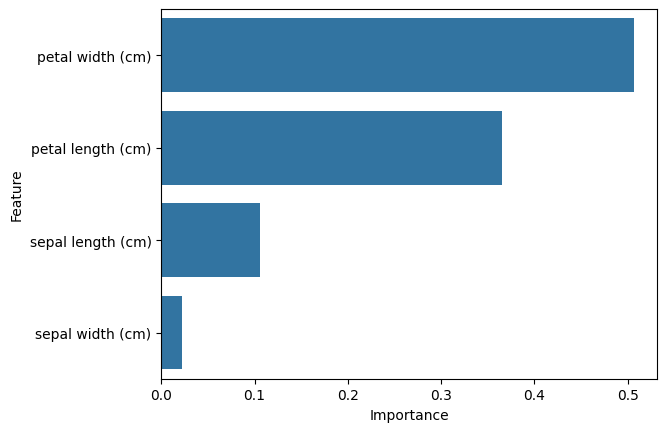

In [ ]:
# app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Load model and data
model = joblib.load("iris_model.pkl")
iris = load_iris()
feature_names = iris.feature_names
target_names = iris.target_names

st.title("🌼 Iris Flower Prediction App")

st.sidebar.header("Input Features")
sepal_length = st.sidebar.slider("Sepal length (cm)", 4.0, 8.0, 5.8)
sepal_width = st.sidebar.slider("Sepal width (cm)", 2.0, 4.5, 3.0)
petal_length = st.sidebar.slider("Petal length (cm)", 1.0, 7.0, 4.2)
petal_width = st.sidebar.slider("Petal width (cm)", 0.1, 2.5, 1.3)

# Prepare input data
input_data = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
input_df = pd.DataFrame(input_data, columns=feature_names)

st.subheader("📥 Your Input")
st.write(input_df)

# Prediction
prediction = model.predict(input_df)[0]
prediction_proba = model.predict_proba(input_df)

st.subheader("🔍 Prediction")
st.write(f"**Predicted Iris Species:** {target_names[prediction]}")

# Probability visualization
st.subheader("📊 Prediction Probabilities")
prob_df = pd.DataFrame(prediction_proba, columns=target_names)
st.bar_chart(prob_df.T)

# Feature importance
st.subheader("📈 Feature Importance")
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.feature_importances_
}).sort_values(by="Importance", ascending=False)

fig, ax = plt.subplots()
sns.barplot(data=importance_df, x="Importance", y="Feature", ax=ax)
st.pyplot(fig)


In [ ]:
%pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.2 MB/s eta 0:00:00
